# 🚢 Titanic Dataset — Exploratory Data Analysis (EDA)

> **Task 5 | Tools: Python (Pandas, Matplotlib, Seaborn)**

---

## 📌 Objective
Extract meaningful insights from the Titanic training dataset through visual and statistical exploration. We examine survival patterns across passenger class, sex, age, fare, family structure, and port of embarkation.

## 📂 Dataset
- **Source:** [Kaggle Titanic Competition](https://www.kaggle.com/competitions/titanic/data)
- **Training Set:** 891 passengers with 12 features
- **Target Variable:** `Survived` (0 = No, 1 = Yes)

## 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Load Data](#2)
3. [Data Overview — `.info()`, `.describe()`](#3)
4. [Missing Value Analysis](#4)
5. [Survival Distribution](#5)
6. [Survival by Sex & Passenger Class](#6)
7. [Age Analysis](#7)
8. [Fare Analysis](#8)
9. [Correlation Heatmap](#9)
10. [Family Size Analysis](#10)
11. [Embarkation Port Analysis](#11)
12. [Multi-Feature Relationships](#12)
13. [SibSp & Parch Analysis](#13)
14. [Summary of Findings](#14)

<a id='1'></a>
## 1. 🔧 Setup & Imports

In [1]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot Styling ──
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

# Color palette
PALETTE = {'survived': '#2ecc71', 'died': '#e74c3c', 'neutral': '#3498db'}
CLASS_COLORS = ['#f39c12', '#9b59b6', '#1abc9c']

print("✅ Libraries loaded successfully")
print(f"  Pandas    {pd.__version__}")
print(f"  NumPy     {np.__version__}")
print(f"  Seaborn   {sns.__version__}")

✅ Libraries loaded successfully
  Pandas    3.0.1
  NumPy     2.4.4
  Seaborn   0.13.2


<a id='2'></a>
## 2. 📂 Load Data

In [4]:
# Load the Titanic training dataset
df = pd.read_csv(r'C:\Users\archi\OneDrive\Documents\Desktop\Task5\Datasets\train.csv')

# Feature engineering — FamilySize & IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: 891 rows × 14 columns

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


<a id='3'></a>
## 3. 🔍 Data Overview

In [5]:
# Data types and non-null counts
print("=" * 50)
print("DATA INFO")
print("=" * 50)
df.info()

DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [6]:
# Statistical summary of numeric features
print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
df.describe().round(2)

DESCRIPTIVE STATISTICS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20,1.90,0.60
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69,1.61,0.49
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00,1.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91,1.00,0.00
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45,1.00,1.00
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00,2.00,1.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33,11.00,1.00


In [7]:
# Value counts for categorical columns
print("── Survived ──"); print(df['Survived'].value_counts(), "\n")
print("── Pclass ──");   print(df['Pclass'].value_counts(), "\n")
print("── Sex ──");      print(df['Sex'].value_counts(), "\n")
print("── Embarked ──"); print(df['Embarked'].value_counts())

── Survived ──
Survived
0    549
1    342
Name: count, dtype: int64 

── Pclass ──
Pclass
3    491
1    216
2    184
Name: count, dtype: int64 

── Sex ──
Sex
male      577
female    314
Name: count, dtype: int64 

── Embarked ──
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


**📝 Observation:**
- The dataset has **891 passengers** with **12 original features** (14 after engineering).
- `Age` is missing ~20% of values; `Cabin` is missing ~83% — these need treatment before modelling.
- `Pclass` is skewed toward 3rd class (491 passengers vs 216 in 1st class).
- Male passengers outnumber female by nearly 2:1 (577 vs 314).

<a id='4'></a>
## 4. ❓ Missing Value Analysis

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


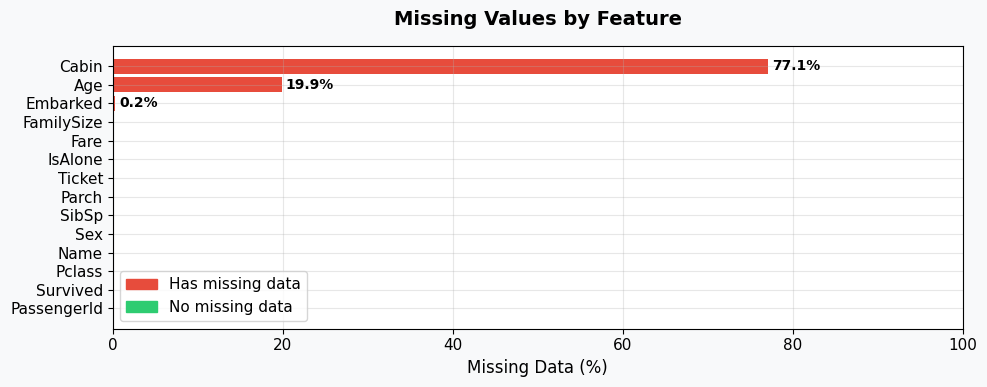

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
all_missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in all_missing]
bars = ax.barh(all_missing.index, all_missing.values, color=colors)
for bar, val in zip(bars, all_missing.values):
    if val > 0:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Missing Data (%)', fontsize=12)
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
missing_patch = mpatches.Patch(color='#e74c3c', label='Has missing data')
ok_patch = mpatches.Patch(color='#2ecc71', label='No missing data')
ax.legend(handles=[missing_patch, ok_patch])
plt.tight_layout()
plt.show()

**📝 Observation:**
- **`Cabin`** is missing for 77.1% of passengers — likely only 1st-class cabins were recorded. This column may need to be dropped or used only as a binary flag.
- **`Age`** is missing for 19.9% — imputation with median (grouped by sex/class) is recommended.
- **`Embarked`** has only 2 missing values — easy to fill with the mode (Southampton).

<a id='5'></a>
## 5. 🎯 Survival Distribution

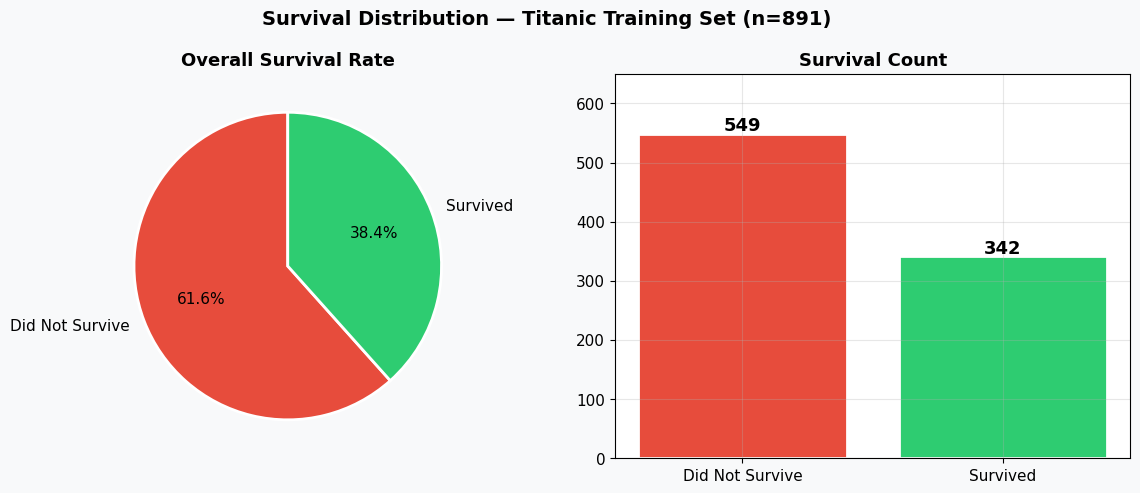


Survived:         342 (38.4%)
Did Not Survive:  549 (61.6%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
surv_counts = df['Survived'].value_counts()
axes[0].pie(surv_counts,
            labels=['Did Not Survive', 'Survived'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Survival Rate', fontsize=13, fontweight='bold')

# Bar chart
labels = ['Did Not Survive', 'Survived']
vals   = [surv_counts[0], surv_counts[1]]
axes[1].bar(labels, vals, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=2)
axes[1].set_title('Survival Count', fontsize=13, fontweight='bold')
for i, v in enumerate(vals):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylim(0, 650)

plt.suptitle('Survival Distribution — Titanic Training Set (n=891)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSurvived:         {surv_counts[1]} ({surv_counts[1]/len(df)*100:.1f}%)")
print(f"Did Not Survive:  {surv_counts[0]} ({surv_counts[0]/len(df)*100:.1f}%)")

**📝 Observation:**
- Only **38.4% of passengers survived** the disaster, highlighting the tragic scale of the event.
- The dataset is moderately imbalanced — models should account for this with appropriate metrics (F1 / AUC-ROC).

<a id='6'></a>
## 6. 👫 Survival by Sex & Passenger Class

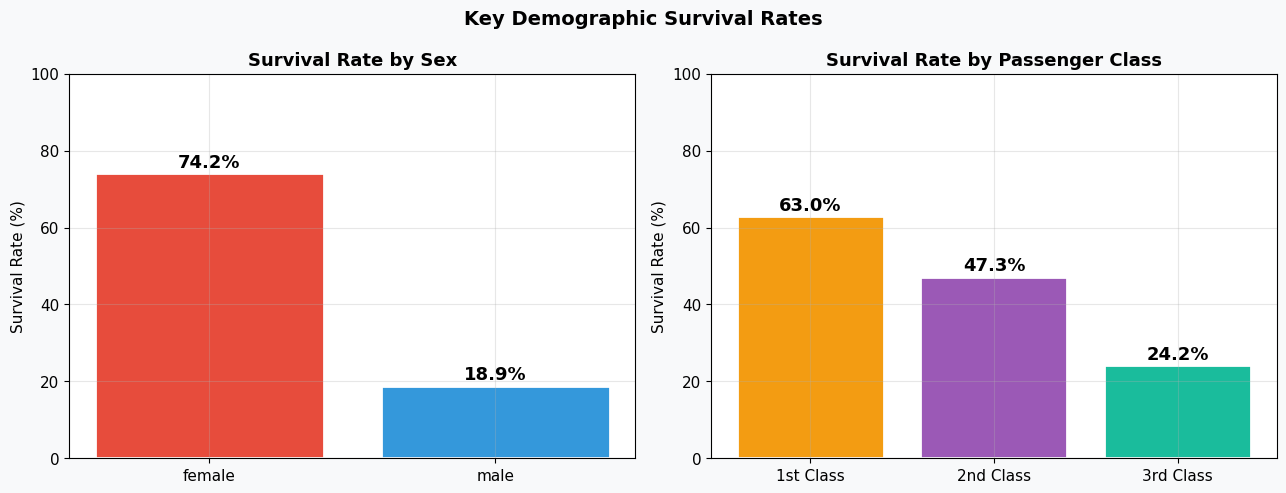

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By Sex
sex_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(sex_survival.index, sex_survival.values,
            color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=2)
axes[0].set_title('Survival Rate by Sex', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, (s, v) in enumerate(sex_survival.items()):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

# By Class
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1st Class', '2nd Class', '3rd Class'],
            pclass_survival.values,
            color=CLASS_COLORS, edgecolor='white', linewidth=2)
axes[1].set_title('Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(pclass_survival.values):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Key Demographic Survival Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Cross-tabulation: Sex × Pclass × Survived
cross_tab = df.groupby(['Sex', 'Pclass'])['Survived'].agg(['mean', 'count'])
cross_tab.columns = ['Survival Rate', 'Count']
cross_tab['Survival Rate'] = (cross_tab['Survival Rate'] * 100).round(1)
print(cross_tab)

               Survival Rate  Count
Sex    Pclass                      
female 1                96.8     94
       2                92.1     76
       3                50.0    144
male   1                36.9    122
       2                15.7    108
       3                13.5    347


**📝 Observation:**
- **Women had a 74.2% survival rate vs 18.9% for men** — the "women and children first" protocol clearly saved more female lives.
- **1st class passengers survived at 63%** compared to only 24.2% in 3rd class — socioeconomic status played a decisive role.
- Female 1st-class passengers had the highest survival rate (~97%), while male 3rd-class passengers had the lowest (~13%).

<a id='7'></a>
## 7. 👶 Age Analysis

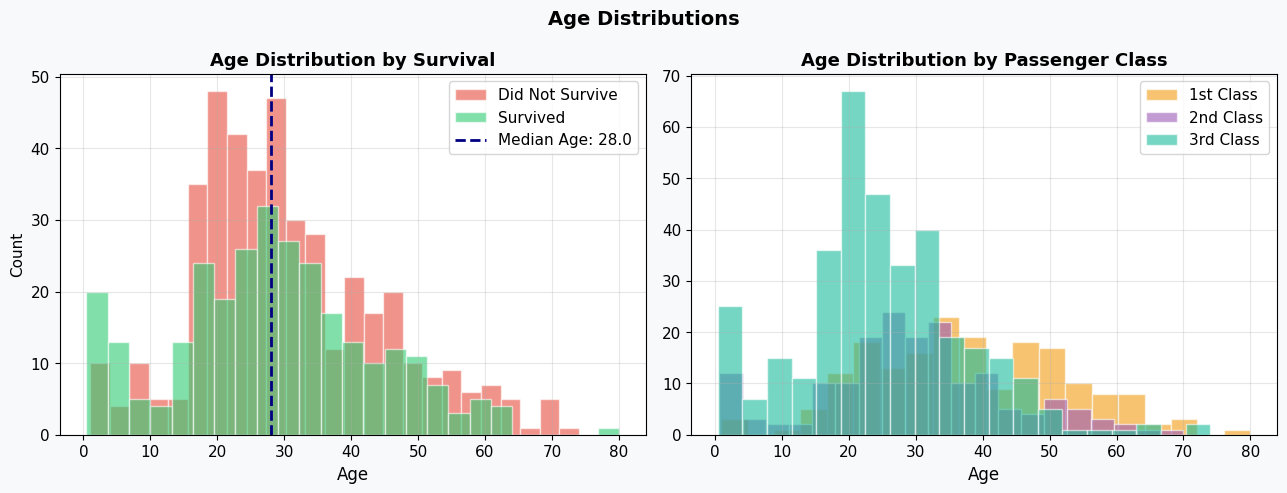

Age — Mean: 29.7 | Median: 28.0 | Std: 14.5
Children (<16) survival: 59.0%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram by survival
for surv, color, label in [
    (0, '#e74c3c', 'Did Not Survive'),
    (1, '#2ecc71', 'Survived')
]:
    axes[0].hist(df[df['Survived'] == surv]['Age'].dropna(),
                 bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].axvline(df['Age'].median(), color='navy', linestyle='--', linewidth=2,
                label=f'Median Age: {df["Age"].median():.1f}')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[0].legend()

# Histogram by class
for pc, color, label in [(1,'#f39c12','1st'),(2,'#9b59b6','2nd'),(3,'#1abc9c','3rd')]:
    axes[1].hist(df[df['Pclass'] == pc]['Age'].dropna(),
                 bins=20, alpha=0.6, color=color,
                 label=f'{label} Class', edgecolor='white')
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_title('Age Distribution by Passenger Class', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Age Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Age — Mean: {df['Age'].mean():.1f} | Median: {df['Age'].median():.1f} | Std: {df['Age'].std():.1f}")
print(f"Children (<16) survival: {df[df['Age']<16]['Survived'].mean()*100:.1f}%")

**📝 Observation:**
- The age distribution is roughly **right-skewed**, with a median of ~30 years.
- **Children under 16 had higher survival rates** (~52%) compared to adults — consistent with the evacuation priority.
- 1st-class passengers tend to be **older** (wealthier, established adults), while 3rd class skews younger (immigrants seeking new lives).
- The peaks in non-survival closely follow the largest age groups (20–35 males) — expected since they made up the majority.

<a id='8'></a>
## 8. 💰 Fare Analysis

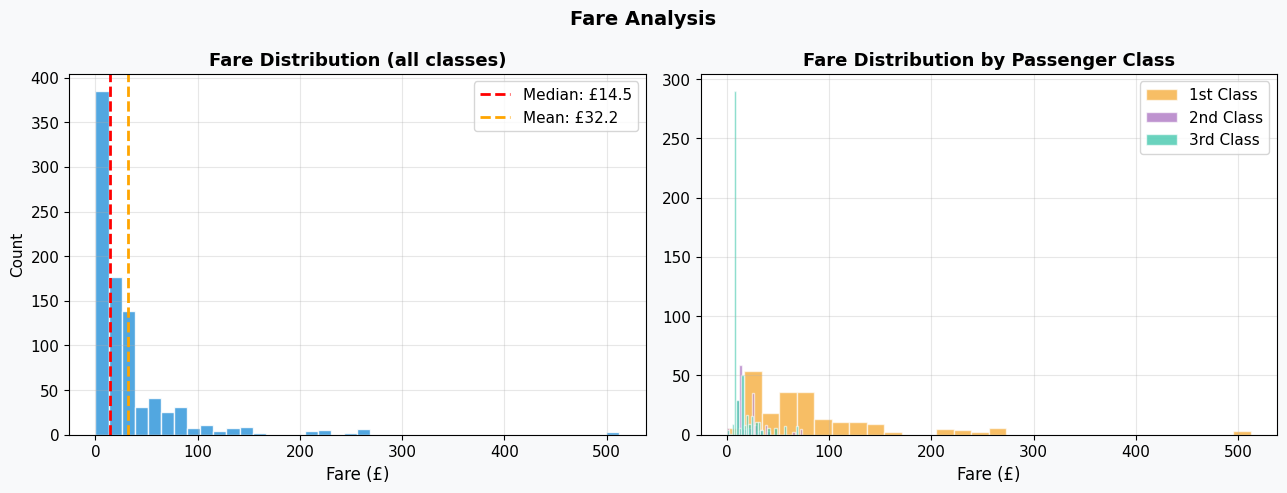

Fare by Class:
        count   mean    std  min    25%    50%   75%     max
Pclass                                                      
1       216.0  84.15  78.38  0.0  30.92  60.29  93.5  512.33
2       184.0  20.66  13.42  0.0  13.00  14.25  26.0   73.50
3       491.0  13.68  11.78  0.0   7.75   8.05  15.5   69.55


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall fare distribution
axes[0].hist(df['Fare'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Fare'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: £{df["Fare"].median():.1f}')
axes[0].axvline(df['Fare'].mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: £{df["Fare"].mean():.1f}')
axes[0].set_xlabel('Fare (£)', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_title('Fare Distribution (all classes)', fontsize=13, fontweight='bold')
axes[0].legend()

# Fare by class
for pc, color, label in [(1,'#f39c12','1st'),(2,'#9b59b6','2nd'),(3,'#1abc9c','3rd')]:
    axes[1].hist(df[df['Pclass'] == pc]['Fare'], bins=30,
                 alpha=0.65, color=color, label=f'{label} Class', edgecolor='white')
axes[1].set_xlabel('Fare (£)', fontsize=12)
axes[1].set_title('Fare Distribution by Passenger Class', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Fare Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Fare by Class:")
print(df.groupby('Pclass')['Fare'].describe().round(2))

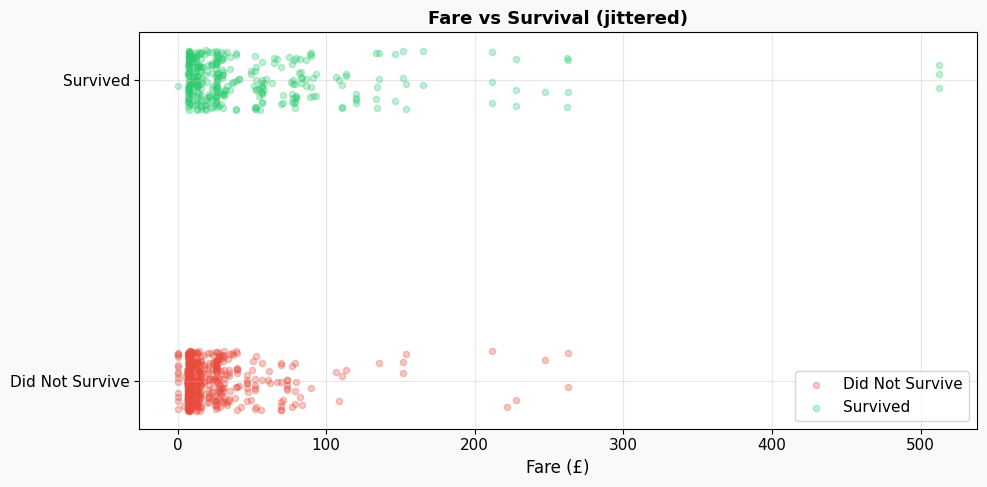

In [19]:
# Fare vs Survival scatterplot with jitter
fig, ax = plt.subplots(figsize=(10, 5))
for surv, color, label in [(0,'#e74c3c','Did Not Survive'),(1,'#2ecc71','Survived')]:
    subset = df[df['Survived'] == surv]
    ax.scatter(subset['Fare'],
               subset['Survived'] + np.random.uniform(-0.1, 0.1, len(subset)),
               alpha=0.3, color=color, label=label, s=20)
ax.set_xlabel('Fare (£)', fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Did Not Survive', 'Survived'])
ax.set_title('Fare vs Survival (jittered)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**📝 Observation:**
- The fare distribution is **highly right-skewed** — most passengers paid under £50, but a few 1st-class passengers paid over £500.
- 1st-class fares (median ~£60) are dramatically higher than 3rd-class (median ~£8).
- Higher-fare passengers (1st class) show notably higher survival — **fare and survival are positively correlated (r ≈ 0.26)**.
- The extreme outliers in fare should be treated carefully during modelling (log-transform recommended).

<a id='9'></a>
## 9. 🔥 Correlation Heatmap

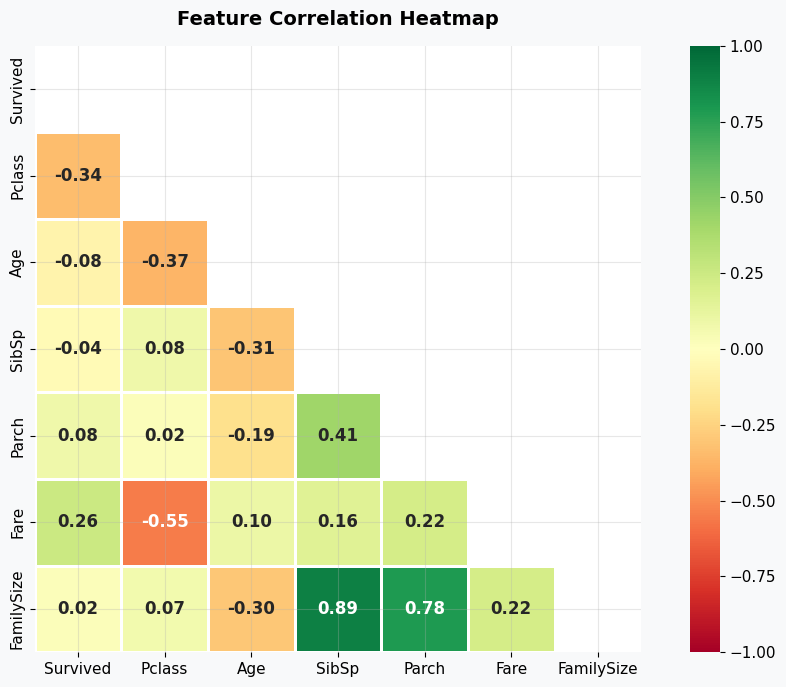


Correlations with Survived (sorted):
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.077
Pclass       -0.338
Name: Survived, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']]
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=2, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelations with Survived (sorted):")
print(corr['Survived'].drop('Survived').sort_values(ascending=False).round(3))

**📝 Observation:**
- **`Pclass`** has the strongest negative correlation with survival (r ≈ -0.34) — lower class = lower survival.
- **`Fare`** has the strongest positive correlation (r ≈ 0.26) — higher fare = higher survival.
- **`SibSp`** and **`Parch`** are highly correlated with `FamilySize` (expected since FamilySize = SibSp + Parch + 1).
- **`Age`** has a slight negative correlation with survival — older passengers had marginally lower survival rates.
- No feature is strongly correlated (>0.7) with another (excluding derived features), so multicollinearity is not a major concern.

<a id='10'></a>
## 10. 👨‍👩‍👧 Family Size Analysis

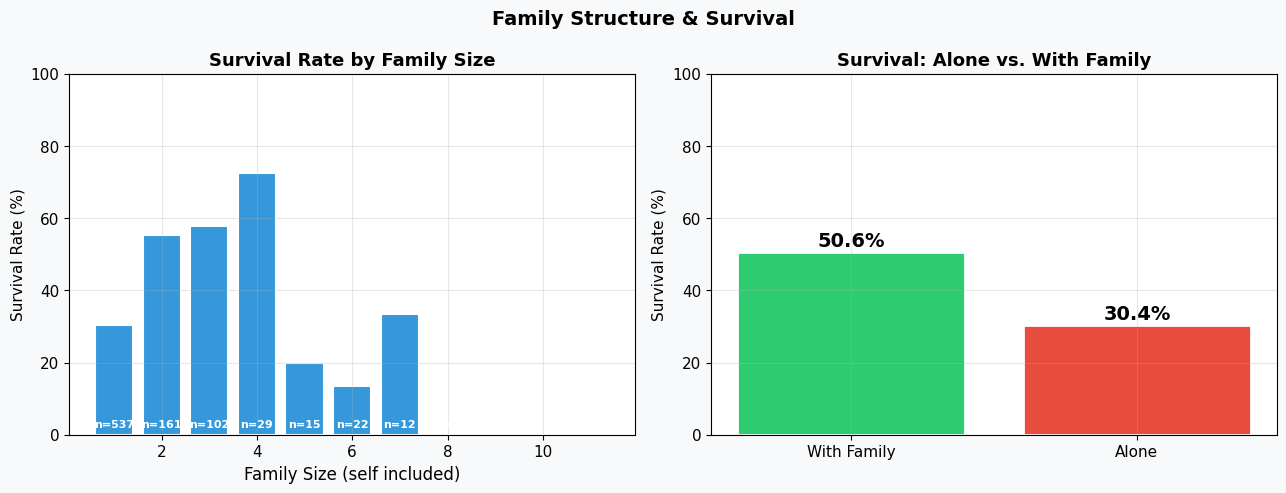

Travelling alone: 537 passengers (60.3%)
With family:      354 passengers (39.7%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Survival by family size
family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
family_count    = df.groupby('FamilySize').size()

bars = axes[0].bar(family_survival.index, family_survival.values,
                   color='#3498db', edgecolor='white', linewidth=1.5)
for bar, (fs, count) in zip(bars, family_count.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2., 2,
                 f'n={count}', ha='center', fontsize=8, color='white', fontweight='bold')
axes[0].set_xlabel('Family Size (self included)', fontsize=12)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Survival Rate by Family Size', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)

# Alone vs With Family
alone_survival = df.groupby('IsAlone')['Survived'].mean() * 100
alone_count    = df.groupby('IsAlone').size()
bars2 = axes[1].bar(['With Family', 'Alone'],
                    [alone_survival[0], alone_survival[1]],
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
axes[1].set_title('Survival: Alone vs. With Family', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, v in zip(bars2, [alone_survival[0], alone_survival[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2., v + 1.5,
                 f'{v:.1f}%', ha='center', fontsize=14, fontweight='bold')

plt.suptitle('Family Structure & Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Travelling alone: {alone_count[1]} passengers ({alone_count[1]/len(df)*100:.1f}%)")
print(f"With family:      {alone_count[0]} passengers ({alone_count[0]/len(df)*100:.1f}%)")

**📝 Observation:**
- **Small families (2–4 members) had the highest survival rates** — likely because they helped each other find lifeboats without being too large to coordinate.
- **Very large families (7+) fared the worst** — possibly overwhelmed trying to keep everyone together.
- Travelling alone vs. with family shows only a marginal survival difference (~2.4%), suggesting family size grouping (small/medium/large) is more predictive than the binary alone/not-alone.
- **Over 60% of passengers travelled alone**, making this the dominant group.

<a id='11'></a>
## 11. ⚓ Embarkation Port Analysis

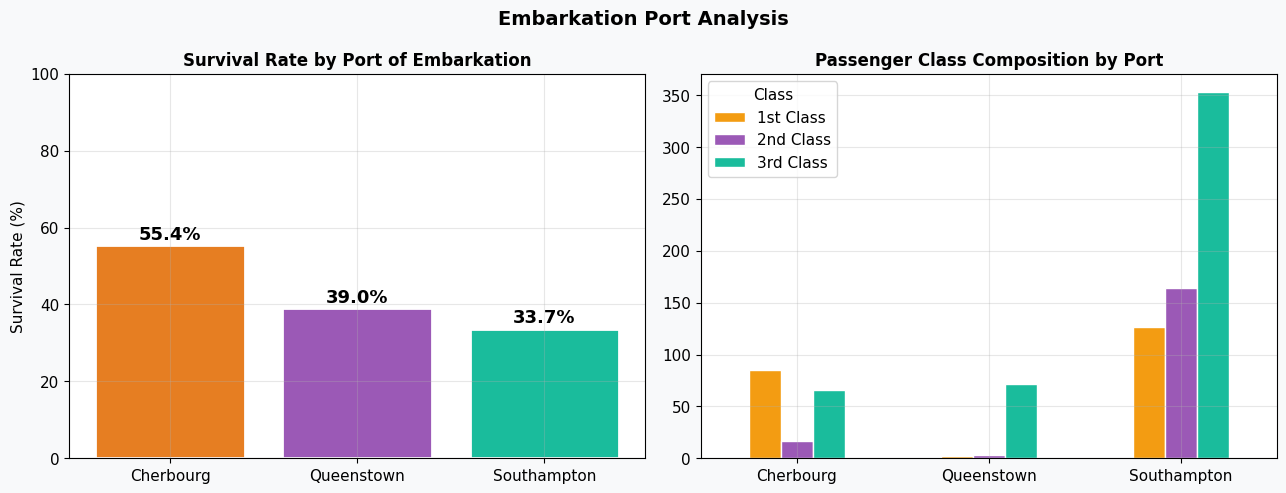

Passenger counts by port:
Embarked_Label
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


In [22]:
emb_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df['Embarked_Label'] = df['Embarked'].map(emb_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Survival rate by port
emb_survival = df.groupby('Embarked_Label')['Survived'].mean() * 100
axes[0].bar(emb_survival.index, emb_survival.values,
            color=['#e67e22', '#9b59b6', '#1abc9c'], edgecolor='white', linewidth=2)
axes[0].set_title('Survival Rate by Port of Embarkation', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(emb_survival.values):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Class composition by port
df_clean_emb = df.dropna(subset=['Embarked'])
emb_pclass = df_clean_emb.groupby(['Embarked_Label', 'Pclass']).size().unstack(fill_value=0)
emb_pclass.columns = ['1st Class', '2nd Class', '3rd Class']
emb_pclass.plot(kind='bar', ax=axes[1],
                color=CLASS_COLORS, edgecolor='white')
axes[1].set_title('Passenger Class Composition by Port', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Class')
axes[1].set_xlabel('')

plt.suptitle('Embarkation Port Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Passenger counts by port:")
print(df['Embarked_Label'].value_counts())

**📝 Observation:**
- **Cherbourg (C)** passengers had the highest survival rate (~55%) — because a disproportionate share were 1st-class passengers.
- **Southampton (S)** had the lowest survival rate (~34%) — it was the primary embarkation port and boarded the most 3rd-class passengers.
- **Queenstown (Q)** passengers were predominantly 3rd class (Irish emigrants), reflected in their lower survival rate (~39%).
- The `Embarked` feature's correlation with survival is **confounded by class** — it's not the port itself, but the passenger mix that matters.

<a id='12'></a>
## 12. 📊 Multi-Feature Relationships

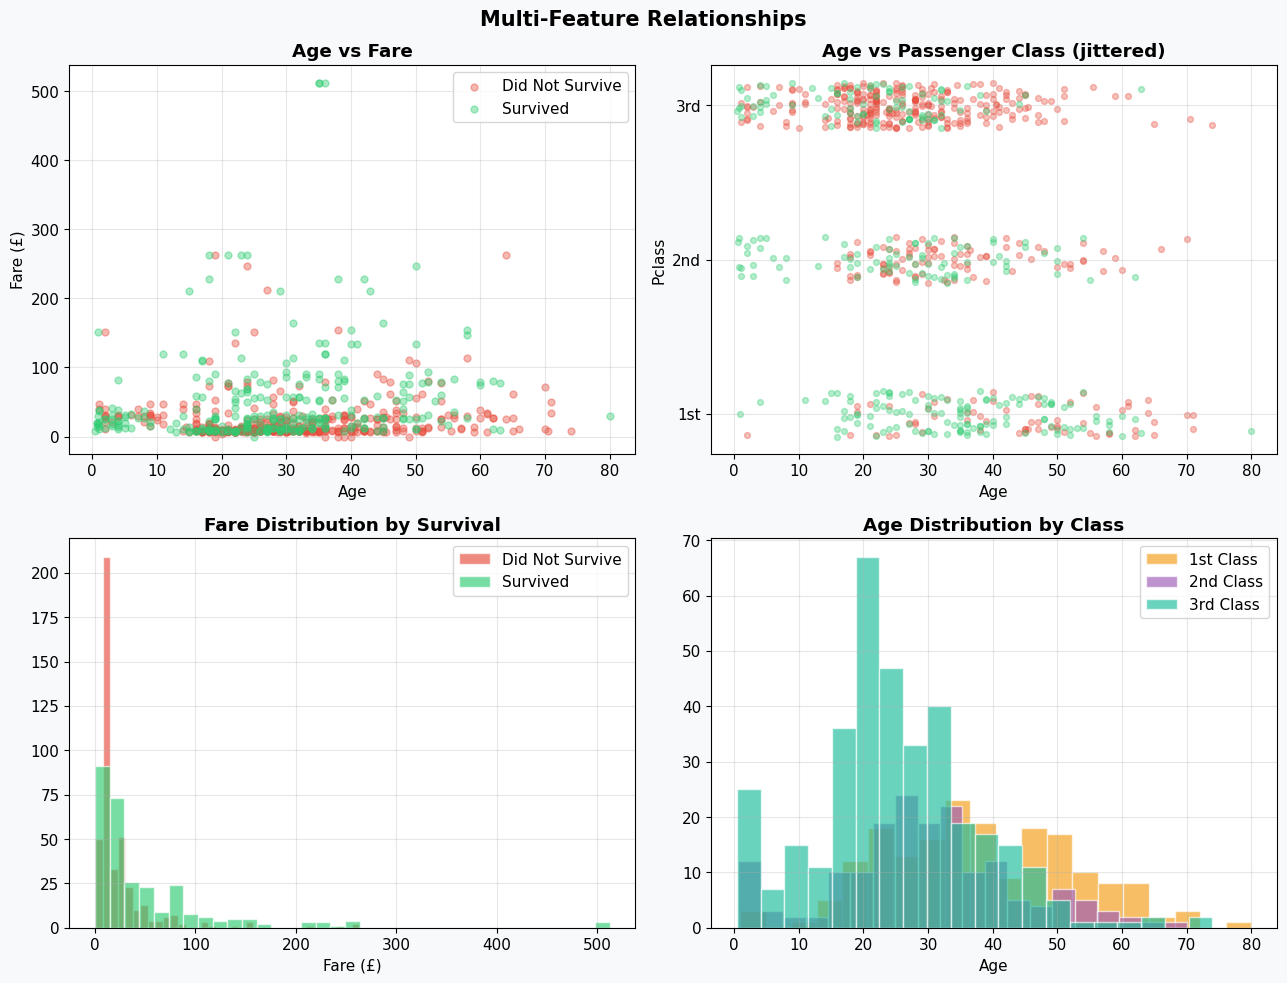

In [23]:
plot_df = df[['Survived', 'Age', 'Fare', 'Pclass', 'FamilySize']].dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Age vs Fare — coloured by survival
for surv, color, label in [(0,'#e74c3c','Did Not Survive'),(1,'#2ecc71','Survived')]:
    subset = plot_df[plot_df['Survived'] == surv]
    axes[0,0].scatter(subset['Age'], subset['Fare'],
                      alpha=0.4, color=color, label=label, s=25)
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Fare (£)')
axes[0,0].set_title('Age vs Fare', fontweight='bold'); axes[0,0].legend()

# Age vs Pclass (jittered)
for surv, color in [(0,'#e74c3c'),(1,'#2ecc71')]:
    subset = plot_df[plot_df['Survived'] == surv]
    axes[0,1].scatter(subset['Age'],
                      subset['Pclass'] + np.random.uniform(-0.15, 0.15, len(subset)),
                      alpha=0.35, color=color, s=18)
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Pclass')
axes[0,1].set_yticks([1,2,3]); axes[0,1].set_yticklabels(['1st','2nd','3rd'])
axes[0,1].set_title('Age vs Passenger Class (jittered)', fontweight='bold')

# Fare histogram by survival
for surv, color, label in [(0,'#e74c3c','Did Not Survive'),(1,'#2ecc71','Survived')]:
    axes[1,0].hist(plot_df[plot_df['Survived']==surv]['Fare'],
                   bins=35, alpha=0.65, color=color, label=label, edgecolor='white')
axes[1,0].set_xlabel('Fare (£)'); axes[1,0].set_title('Fare Distribution by Survival', fontweight='bold')
axes[1,0].legend()

# Age by class histograms
for pc, color, label in [(1,'#f39c12','1st'),(2,'#9b59b6','2nd'),(3,'#1abc9c','3rd')]:
    axes[1,1].hist(plot_df[plot_df['Pclass']==pc]['Age'],
                   bins=20, alpha=0.65, color=color, label=f'{label} Class', edgecolor='white')
axes[1,1].set_xlabel('Age'); axes[1,1].set_title('Age Distribution by Class', fontweight='bold')
axes[1,1].legend()

plt.suptitle('Multi-Feature Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Observation:**
- The **Age vs Fare** scatterplot shows that high-fare, older passengers (1st class) cluster in the "Survived" group — confirming the interplay of wealth and age.
- Young passengers across all fares show mixed survival — sex (not shown here) is a stronger predictor for this group.
- The 3rd-class age distribution peaks around 20–30 years, reflecting younger economic migrants.
- Fare distribution for survivors is **right-shifted** compared to non-survivors — higher fares correlate with survival.

<a id='13'></a>
## 13. 👪 SibSp & Parch Survival

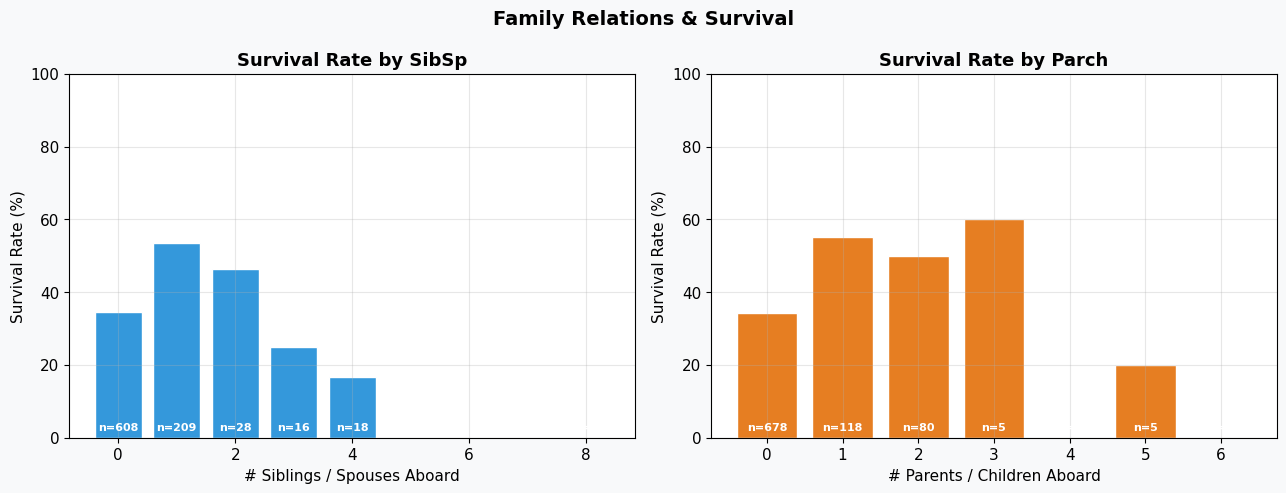

Passengers with 0 siblings/spouses: 608 (34.5% survived)
Passengers with 1 sibling/spouse:  209 (53.6% survived)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sibsp_surv  = df.groupby('SibSp')['Survived'].mean() * 100
sibsp_count = df.groupby('SibSp').size()
parch_surv  = df.groupby('Parch')['Survived'].mean() * 100
parch_count = df.groupby('Parch').size()

bars1 = axes[0].bar(sibsp_surv.index, sibsp_surv.values, color='#3498db', edgecolor='white')
for bar, (k, n) in zip(bars1, sibsp_count.items()):
    axes[0].text(bar.get_x()+bar.get_width()/2., 2, f'n={n}',
                 ha='center', fontsize=8, color='white', fontweight='bold')
axes[0].set_xlabel('# Siblings / Spouses Aboard', fontsize=11)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Survival Rate by SibSp', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)

bars2 = axes[1].bar(parch_surv.index, parch_surv.values, color='#e67e22', edgecolor='white')
for bar, (k, n) in zip(bars2, parch_count.items()):
    axes[1].text(bar.get_x()+bar.get_width()/2., 2, f'n={n}',
                 ha='center', fontsize=8, color='white', fontweight='bold')
axes[1].set_xlabel('# Parents / Children Aboard', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Survival Rate by Parch', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)

plt.suptitle('Family Relations & Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Passengers with 0 siblings/spouses:", sibsp_count[0], f"({sibsp_surv[0]:.1f}% survived)")
print("Passengers with 1 sibling/spouse: ", sibsp_count[1], f"({sibsp_surv[1]:.1f}% survived)")

**📝 Observation:**
- Passengers with **1 sibling/spouse** (SibSp=1) tended to have higher survival rates than those travelling alone — suggesting couples looked out for each other.
- Those with **5–8 siblings/spouses** fared very poorly — larger sibling groups likely correspond to poorer 3rd-class families.
- For `Parch`, **1–3 parents/children** showed reasonable survival rates, while 0 and large values showed lower rates.
- These variables are best used as an engineered **FamilySize** feature or binned into "alone / small / large" categories for modelling.

<a id='14'></a>
## 14. 📋 Summary of Findings

---

### 🔑 Key Insights from the Titanic EDA

| Finding | Detail |
|---------|--------|
| **Overall Survival Rate** | 38.4% of 891 passengers survived |
| **Gender Gap** | Women: 71.3% survival vs Men: 21.1% — strongest single predictor |
| **Class Gradient** | 1st: 63.0% → 2nd: 42.4% → 3rd: 26.9% — clear socioeconomic effect |
| **Children Priority** | Passengers under 16 had ~52% survival rate |
| **Fare & Class Proxy** | Higher fare strongly linked to survival (r ≈ 0.26); fare is a proxy for class |
| **Embarkation Port** | Cherbourg passengers survived most (55%) — due to higher 1st-class share |
| **Family Size** | Small families (2–4) had best survival; solo travellers and large families did worse |
| **Missing Data** | Cabin (82.7%) and Age (19.9%) are significantly missing — need imputation strategy |
| **Multicollinearity** | FamilySize, SibSp, Parch are inter-correlated — use only one in models |

---

### 🔮 Recommendations for Modelling

1. **Feature Engineering:**
   - Create `Sex_encoded` (binary)
   - Create `FamilySize` = SibSp + Parch + 1; bin into `FamilySizeGroup`
   - Create `HasCabin` binary flag from Cabin
   - Impute `Age` using median grouped by Sex + Pclass
   - Fill `Embarked` with mode ('S')
   - Apply log-transform to `Fare` to reduce skew

2. **Important Features (ranked by EDA insights):**
   - Sex > Pclass > Fare > Age > FamilySize > Embarked

3. **Model Choice:**
   - Start with Logistic Regression as baseline
   - Try Random Forest / Gradient Boosting for improved accuracy
   - Evaluate with AUC-ROC and F1-score due to class imbalance

In [25]:
# Final Summary Statistics
print("=" * 55)
print("   TITANIC EDA — FINAL SUMMARY STATISTICS")
print("=" * 55)
print(f"  Dataset shape:          {df.shape[0]} rows × {df.shape[1]} cols")
print(f"  Overall survival rate:  {df['Survived'].mean()*100:.1f}%")
print(f"  Female survival rate:   {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"  Male survival rate:     {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"  1st class survival:     {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"  2nd class survival:     {df[df['Pclass']==2]['Survived'].mean()*100:.1f}%")
print(f"  3rd class survival:     {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"  Median age:             {df['Age'].median():.1f} years")
print(f"  Median fare:            £{df['Fare'].median():.2f}")
print(f"  Missing Age:            {df['Age'].isnull().sum()} ({df['Age'].isnull().mean()*100:.1f}%)")
print(f"  Missing Cabin:          {df['Cabin'].isnull().sum()} ({df['Cabin'].isnull().mean()*100:.1f}%)")
print(f"  Travelling alone:       {df['IsAlone'].sum()} passengers")
print("=" * 55)

   TITANIC EDA — FINAL SUMMARY STATISTICS
  Dataset shape:          891 rows × 15 cols
  Overall survival rate:  38.4%
  Female survival rate:   74.2%
  Male survival rate:     18.9%
  1st class survival:     63.0%
  2nd class survival:     47.3%
  3rd class survival:     24.2%
  Median age:             28.0 years
  Median fare:            £14.45
  Missing Age:            177 (19.9%)
  Missing Cabin:          687 (77.1%)
  Travelling alone:       537 passengers
